# Beyond Small Strain: Proving the Importance of Finite Strain Theory

**PGE 383 – Advanced Geomechanics | Prof. Nicholas Espinoza**  
**Syed Talha Tirmizi | PhD Candidate, PGE, The University of Texas at Austin**  
**April 2026**

---

## Table of Contents
1. [Purpose and Scope](#1.-Purpose-and-Scope)
2. [Notation and Configurations](#2.-Notation-and-Configurations)
3. [Weak Forms, Test Functions, and Boundary Integrals](#3.-Weak-Forms,-Test-Functions,-and-Boundary-Integrals)
4. [Stress Measures in Small and Large Strain](#4.-Stress-Measures-in-Small-and-Large-Strain)
5. [Small-Strain Poromechanics Weak Form](#5.-Small-Strain-Poromechanics-Weak-Form)
6. [Large-Strain Total Lagrangian Poromechanics Weak Form](#6.-Large-Strain-Total-Lagrangian-Poromechanics-Weak-Form)
7. [MOOSE Kernel Architecture and Input File Setup](#7.-MOOSE-Kernel-Architecture-and-Input-File-Setup)
8. [Analytical Solution of 1D Terzaghi Consolidation](#8.-Analytical-Solution-of-1D-Terzaghi-Consolidation)
9. [Numerical Model Setups](#9.-Numerical-Model-Setups)
10. [Plotting Functions Library](#10.-Plotting-Functions-Library)
11. [Results: Classical Model (Analytical Benchmark)](#11.-Results:-Classical-Model-(Analytical-Benchmark))
12. [Results: Classical Model – Load = 100 kPa](#12.-Results:-Classical-Model-–-Load-=-100-kPa)
13. [Results: Classical Model – Load = 500 kPa](#13.-Results:-Classical-Model-–-Load-=-500-kPa)
14. [Results: Bi-layer Model – Load = 1 kPa](#14.-Results:-Bi-layer-Model-–-Load-=-1-kPa)
15. [Results: Bi-layer Model – Load = 100 kPa / 150 kPa](#15.-Results:-Bi-layer-Model-–-Load-=-100-kPa-/-150-kPa)
16. [Discussion](#16.-Discussion)
17. [Conclusion](#17.-Conclusion)
18. [References](#18.-References)

---
## 1. Purpose and Scope

This notebook documents the continuum-mechanics background, weak forms, analytical solution,  MOOSE implementation details, and numerical results for coupled poromechanical consolidation problems. The small-strain and large-strain formulations are compared directly.

The two primary unknown fields are the **solid displacement field** $\mathbf{u}$ and the **excess pore pressure field** $p$. In a 2D computational setting:

$$\mathbf{u} = u_x\,\mathbf{e}_x + u_y\,\mathbf{e}_y$$

One-dimensional consolidation is recovered by applying roller side constraints and appropriate hydraulic boundary conditions.

**Sign convention:** tensile stress is positive; pore pressure is compressive. The total stress decomposes as:

$$\boldsymbol{\sigma}_{\mathrm{total}} = \boldsymbol{\sigma}' - \alpha p\,\mathbf{I}$$

where $\boldsymbol{\sigma}'$ is the effective stress, $\alpha$ is the Biot coefficient, $p$ is the pore pressure, and $\mathbf{I}$ is the identity tensor.

---
## 2. Notation and Configurations

A material point is labeled by its **reference coordinate** $\mathbf{X} \in \Omega_0$. After deformation, the same point occupies the **spatial position** $\mathbf{x} \in \Omega_t$. The **motion map** is:

$$\boldsymbol{\varphi}: \Omega_0 \rightarrow \Omega_t, \qquad \mathbf{x} = \boldsymbol{\varphi}(\mathbf{X},t) = \mathbf{X} + \mathbf{u}(\mathbf{X},t)$$

### Deformation Gradient

$$\mathbf{F} = \frac{\partial \mathbf{x}}{\partial \mathbf{X}} = \nabla_0\boldsymbol{\varphi} = \mathbf{I} + \nabla_0\mathbf{u}$$

It maps differential material line elements: $d\mathbf{x} = \mathbf{F}\,d\mathbf{X}$.

### Jacobian (Local Volume Change)

$$J = \det\mathbf{F}, \qquad dV = J\,dV_0$$

- $J > 1$: local expansion  
- $J < 1$: local compression  
- $J = 1$: volume-preserving deformation

### Strain Measures

The **right Cauchy–Green tensor**: $\mathbf{C} = \mathbf{F}^T\mathbf{F}$

The **Green–Lagrange strain tensor** (large strain):

$$\mathbf{E} = \frac{1}{2}\left(\mathbf{C} - \mathbf{I}\right) = \frac{1}{2}\left(\nabla_0\mathbf{u} + \nabla_0\mathbf{u}^T + \nabla_0\mathbf{u}^T\nabla_0\mathbf{u}\right)$$

The **Cauchy (infinitesimal) strain tensor** (small strain, quadratic term dropped):

$$\boldsymbol{\varepsilon} = \frac{1}{2}\left(\nabla\mathbf{u} + \nabla\mathbf{u}^T\right)$$

> **Key insight:** The quadratic term $\nabla_0\mathbf{u}^T\nabla_0\mathbf{u}$ is the fundamental difference between the two formulations. Neglecting it linearises the kinematics — valid only when displacements are small.

---
## 3. Weak Forms, Test Functions, and Boundary Integrals

A **weak form** is obtained by multiplying the governing PDE (strong form) by a test function and integrating over the domain. Test functions vanish on Dirichlet (essential) boundaries.

| Field | Test function | Constraint |
|-------|--------------|------------|
| Displacement $\mathbf{u}$ | Virtual displacement $\delta\mathbf{u}$ | $\delta\mathbf{u} = \mathbf{0}$ on $\Gamma_u$ |
| Pore pressure $p$ | Virtual pressure $\psi$ | $\psi = 0$ on $\Gamma_p$ |

### Integration by Parts (Divergence Theorem)

When applied to stress divergence terms:

$$\int_\Omega (\nabla\cdot\boldsymbol{\sigma})\cdot\delta\mathbf{u}\,dV = \int_{\partial\Omega}(\boldsymbol{\sigma}\mathbf{n})\cdot\delta\mathbf{u}\,dA - \int_\Omega \boldsymbol{\sigma}:\nabla\delta\mathbf{u}\,dV$$

The boundary term naturally introduces the **traction vector** $\mathbf{t} = \boldsymbol{\sigma}\mathbf{n}$ (Neumann condition).

### Virtual Strain Measures

**Small strain:**
$$\delta\boldsymbol{\varepsilon} = \frac{1}{2}\left(\nabla\delta\mathbf{u} + \nabla\delta\mathbf{u}^T\right)$$

**Large strain (Total Lagrangian):**
$$\delta\mathbf{F} = \nabla_0\delta\mathbf{u}, \qquad \delta\mathbf{E} = \frac{1}{2}\left(\mathbf{F}^T\delta\mathbf{F} + \delta\mathbf{F}^T\mathbf{F}\right)$$

---
## 4. Stress Measures in Small and Large Strain

### 4.1 Cauchy Stress (Small Strain / Spatial)

The **Cauchy stress** $\boldsymbol{\sigma}$ acts on surfaces in the *current* configuration:

$$\mathbf{t} = \boldsymbol{\sigma}\mathbf{n}$$

It is the natural stress measure for small-strain and Eulerian descriptions.

### 4.2 First Piola–Kirchhoff Stress (PK1)

The **PK1 stress** $\mathbf{P}$ maps *reference* area normals to *current* force vectors:

$$\bar{\mathbf{t}}_0 = \mathbf{P}\mathbf{N}, \qquad \mathbf{P} = J\boldsymbol{\sigma}\mathbf{F}^{-T}$$

It is **not symmetric** (connects two different configurations). Work-conjugate to $\delta\mathbf{F}$:

$$\delta W_{\mathrm{int}} = \int_{\Omega_0} \mathbf{P}:\delta\mathbf{F}\,dV_0$$

### 4.3 Second Piola–Kirchhoff Stress (PK2)

The **PK2 stress** $\mathbf{S}$ is a fully material (reference-configuration) measure:

$$\mathbf{P} = \mathbf{F}\mathbf{S}, \qquad \mathbf{S} = \mathbf{F}^{-1}\mathbf{P} = J\mathbf{F}^{-1}\boldsymbol{\sigma}\mathbf{F}^{-T}$$

$\mathbf{S}$ is **symmetric** and work-conjugate to the Green–Lagrange strain $\delta\mathbf{E}$:

$$\delta W_{\mathrm{int}} = \int_{\Omega_0} \mathbf{S}:\delta\mathbf{E}\,dV_0$$

This makes it the preferred choice in Total Lagrangian formulations.

---
## 5. Small-Strain Poromechanics Weak Form

### 5.1 Solid Mechanics: Equilibrium

**Strong form:**
$$\nabla \cdot \boldsymbol{\sigma}_{\mathrm{total}} + \mathbf{b} = \mathbf{0} \qquad \text{in } \Omega$$

Multiplying by $\delta\mathbf{u}$, integrating, applying the divergence theorem and Neumann BC $\bar{\mathbf{t}} = \boldsymbol{\sigma}_{\mathrm{total}}\mathbf{n}$ on $\Gamma_t$:

$$-\int_\Omega \boldsymbol{\sigma}_{\mathrm{total}}:\delta\boldsymbol{\varepsilon}\,dV + \int_{\Gamma_t}\bar{\mathbf{t}}\cdot\delta\mathbf{u}\,dA + \int_\Omega \mathbf{b}\cdot\delta\mathbf{u}\,dV = 0$$

Substituting $\boldsymbol{\sigma}_{\mathrm{total}} = \boldsymbol{\sigma}' - \alpha p\mathbf{I}$ and using $\mathbf{I}:\delta\boldsymbol{\varepsilon} = \nabla\cdot\delta\mathbf{u}$:

$$\boxed{\int_\Omega \delta\boldsymbol{\varepsilon}:\boldsymbol{\sigma}'\,dV - \int_\Omega \alpha p(\nabla\cdot\delta\mathbf{u})\,dV = \int_\Omega \delta\mathbf{u}\cdot\mathbf{b}\,dV + \int_{\Gamma_t}\delta\mathbf{u}\cdot\bar{\mathbf{t}}\,dA}$$

### 5.2 Fluid Flow: Mass Conservation

**Strong form** (Biot's consolidation):
$$\alpha\nabla\cdot\dot{\mathbf{u}} + S_\epsilon\dot{p} - \nabla\cdot\left(\frac{\mathbf{k}}{\mu_f}\nabla p\right) = 0$$

where $S_\epsilon$ is the constrained specific storage, $\mathbf{k}$ is the intrinsic permeability tensor, and $\mu_f$ is the fluid viscosity.

Multiplying by $\psi$, integrating, applying integration by parts on the flux-divergence term:

$$\boxed{\int_\Omega \psi\,\alpha(\nabla\cdot\dot{\mathbf{u}})\,dV + \int_\Omega \psi S_\epsilon \dot{p}\,dV + \int_\Omega \nabla\psi\cdot\left(\frac{\mathbf{k}}{\mu_f}\nabla p\right)dV = \int_{\Gamma_q}\psi\,\bar{q}_n\,dA}$$

> In the **small-strain** formulation, the geometry $\Omega$, permeability $\mathbf{k}/\mu_f$, and drainage path $H$ are all **fixed** throughout the simulation — a key simplification.

---
## 6. Large-Strain Total Lagrangian Poromechanics Weak Form

### 6.1 Solid Mechanics: Equilibrium

**Strong form** (over reference configuration $\Omega_0$):
$$\nabla_0 \cdot \mathbf{P} + \mathbf{b}_0 = \mathbf{0} \qquad \text{in } \Omega_0$$

Multiplying by $\delta\mathbf{u}$, integrating over $\Omega_0$, and using $\mathbf{P} = \mathbf{F}\mathbf{S}$ (so $\mathbf{P}:\delta\mathbf{F} = \mathbf{S}_{\mathrm{total}}:\delta\mathbf{E}$):

$$\boxed{\int_{\Omega_0} \delta\mathbf{E}:\mathbf{S}_{\mathrm{total}}\,dV_0 = \int_{\Omega_0}\delta\mathbf{u}\cdot\mathbf{b}_0\,dV_0 + \int_{\Gamma_{t,0}}\delta\mathbf{u}\cdot\bar{\mathbf{t}}_0\,dA_0}$$

**Pressure coupling via Piola pull-back.** Starting from $\boldsymbol{\sigma}_{\mathrm{total}} = \boldsymbol{\sigma}' - \alpha p\mathbf{I}$, the total PK2 stress is:

$$\mathbf{S}_{\mathrm{total}} = \mathbf{S}' - \alpha p J\mathbf{C}^{-1}$$

where $\mathbf{C}^{-1} = \mathbf{F}^{-T}\mathbf{F}^{-1}$ and $J\mathbf{C}^{-1}$ maps pressure from the current to the reference domain.

### 6.2 Fluid Flow: Mass Conservation (Total Lagrangian)

**Euler's identity** (volumetric coupling via Jacobian rate): $\dot{J} = J\nabla_x\cdot\mathbf{v}_s$

**Piola identity** (flux pull-back): $J\nabla_x\cdot\mathbf{q} = \nabla_0\cdot\mathbf{Q}$, where $\mathbf{Q} = J\mathbf{F}^{-1}\mathbf{q}$

**Strong form** (pulled back to $\Omega_0$):
$$\alpha\dot{J} + \nabla_0\cdot\mathbf{Q} + JS_\epsilon\dot{p} = 0$$

**Pulled-back (deformation-dependent) permeability tensor:**
$$\mathbf{K}_{\mathrm{TL}} = J\mathbf{F}^{-1}\mathbf{k}\mathbf{F}^{-T}$$

**Weak form** (after integration by parts on the flux term):

$$\boxed{\underbrace{\int_{\Omega_0}\psi\,\alpha\dot{J}\,dV_0}_{\text{volumetric coupling}} + \underbrace{\int_{\Omega_0}\psi\,JS_\epsilon\dot{p}\,dV_0}_{\text{fluid storage}} + \underbrace{\int_{\Omega_0}\nabla_0\psi\cdot\left(\frac{\mathbf{K}_{\mathrm{TL}}}{\mu_f}\nabla_0 p\right)dV_0}_{\text{Darcy flow}} = \int_{\Gamma_{q,0}}\psi\,\bar{Q}_n\,dA_0}$$

> **Critical distinction from small strain:** The $\dot{J}$ term (instead of $\nabla\cdot\dot{\mathbf{u}}$) and the deformation-dependent $\mathbf{K}_{\mathrm{TL}}$ mean that the hydraulic problem *updates itself* as the skeleton deforms. The domain, drainage path, and transport tensor all evolve in time.

---
## 7. MOOSE Kernel Architecture and Input File Setup

### 7.1 How MOOSE Kernels Implement the Weak Form

MOOSE (Multiphysics Object-Oriented Simulation Environment) solves PDEs in **weak form**. Each `[Kernels]` block object contributes one **volumetric integral term** from the weak form to the residual vector. The FEM assembly loop sums these contributions over all elements and quadrature points.

The general residual contribution of a kernel is:
$$R_i = \int_{\Omega_e} f(\mathbf{u}, p, \nabla\mathbf{u}, \nabla p, \ldots) \cdot \phi_i \, dV_e$$

where $\phi_i$ is the test function (shape function) for DOF $i$.

#### Small-Strain Kernel Mapping

| Weak Form Term | MOOSE Kernel Class | Variable |
|---|---|---|
| $\int_\Omega \delta\boldsymbol{\varepsilon}:\boldsymbol{\sigma}'\,dV$ | `SmallStrainMechanicsAD` | $u_x$, $u_y$ |
| $-\int_\Omega \alpha p(\nabla\cdot\delta\mathbf{u})\,dV$ | `SmallStrainMechanicsAD` (coupling) | $u_x$, $u_y$, $p$ |
| $\int_\Omega \psi\,\alpha(\nabla\cdot\dot{\mathbf{u}})\,dV$ | `SmallStrainBiotDivergenceAD` | $p$ (coupled to $u_x$, $u_y$) |
| $\int_\Omega \psi S_\epsilon\dot{p}\,dV + \int_\Omega \nabla\psi\cdot\frac{\mathbf{k}}{\mu_f}\nabla p\,dV$ | `SmallStrainDiffusionAndStorageAD` | $p$ |

#### Large-Strain Kernel Mapping

| Weak Form Term | MOOSE Kernel Class | Variable |
|---|---|---|
| $\int_{\Omega_0} \delta\mathbf{E}:\mathbf{S}_{\mathrm{total}}\,dV_0$ | `LargeStrainMechanicsAD` | $u_x$, $u_y$ |
| $\int_{\Omega_0}\psi\,\alpha\dot{J}\,dV_0$ | `LargeStrainBiotDivergenceAD` | $p$ (coupled to $u_x$, $u_y$) |
| $\int_{\Omega_0}\psi\,JS_\epsilon\dot{p}\,dV_0 + \int_{\Omega_0}\nabla_0\psi\cdot\frac{\mathbf{K}_{\mathrm{TL}}}{\mu_f}\nabla_0 p\,dV_0$ | `LargeStrainDiffusionAndStorageAD` | $p$ (coupled to $u_x$, $u_y$) |

The key additional coupling in the large-strain kernels is that `LargeStrainDiffusionAndStorageAD` and `LargeStrainBiotDivergenceAD` both depend on $u_x$ and $u_y$ (dashed arrows in the coupling diagram below), because they must compute $\mathbf{F}$, $J$, and $\mathbf{K}_{\mathrm{TL}}$ at every quadrature point at every Newton iteration.

```
Large-Strain Consolidation Network
────────────────────────────────────────────────────────────────
              [Variables]
          ux          uy          p
           ↑           ↑          ↑
           |           |          |
 ┌─────────────┐ ┌─────────────┐ ┌──────────────────┐ ┌────────────────────────────────┐
 │  mech_x     │ │  mech_y     │ │  biot_div_ad     │ │  p_diffusion                   │
 │ (LargeStrain│ │ (LargeStrain│ │ (LargeStrainBiot │ │ (LargeStrainDiffusionAnd       │
 │  MechanicsAD│ │  MechanicsAD│ │  DivergenceAD)   │ │  StorageAD)                    │
 └─────────────┘ └─────────────┘ └──────────────────┘ └────────────────────────────────┘
       [Kernels] — solid lines = operates on primary var; dashed = coupled dependency
```

### 7.2 MOOSE Input File Structure

Each MOOSE simulation is driven by an **input file** (`.i` extension, HIT format). Below is an annotated excerpt showing the structure used in this project.

```ini
# ============================================================
# large_strain_consolidation.i
# 1D homogeneous consolidation — Large Strain Total Lagrangian
# ============================================================

[Mesh]
  # Generate a 1x300 column mesh: 1 m wide, 10 m tall
  type = GeneratedMesh
  dim  = 2
  nx   = 1
  ny   = 300
  xmax = 1.0
  ymax = 10.0
  elem_type = QUAD9   # Quadratic (9-node) quads for accuracy
[]

[Variables]
  # Primary unknowns solved simultaneously (fully coupled)
  [ux]  order = SECOND  family = LAGRANGE  []
  [uy]  order = SECOND  family = LAGRANGE  []
  [p]   order = FIRST   family = LAGRANGE  []   # Pore pressure
[]

[Kernels]
  # ── Solid mechanics (equilibrium weak form) ──────────────────
  # Implements: ∫ δE : S_total dV₀  (PK2 stress, Green-Lagrange E)
  # F and J are computed internally at each quadrature point.
  [mech_x]
    type     = LargeStrainMechanicsAD
    variable = ux
    component = 0
    displacements = 'ux uy'
    pore_pressure = p
    biot_coefficient = 1.0
  []
  [mech_y]
    type     = LargeStrainMechanicsAD
    variable = uy
    component = 1
    displacements = 'ux uy'
    pore_pressure = p
    biot_coefficient = 1.0
  []

  # ── Biot volumetric coupling term ─────────────────────────────
  # Implements: ∫ ψ α J̇ dV₀   (Euler's identity pulled back)
  # This is the CRITICAL large-strain term: J̇ = J ∇ₓ·vs
  # It replaces the small-strain α ∇·u̇ term.
  [biot_div_ad]
    type          = LargeStrainBiotDivergenceAD
    variable      = p
    displacements = 'ux uy'
    biot_coefficient = 1.0
  []

  # ── Darcy flow + fluid storage ────────────────────────────────
  # Implements: ∫ ψ J Sε ṗ dV₀  +  ∫ ∇₀ψ · (K_TL/μ ∇₀p) dV₀
  # K_TL = J F⁻¹ k F⁻ᵀ  —  pulled-back, deformation-dependent!
  # This kernel ALSO depends on ux,uy because it computes F and J.
  [p_diffusion]
    type          = LargeStrainDiffusionAndStorageAD
    variable      = p
    displacements = 'ux uy'
    fluid_mobility = 1e-6        # κ/μ  [m²/(kPa·day)]
    specific_storage = 1e-7      # Sε   [kPa⁻¹]
    biot_coefficient = 1.0
  []
[]

[Materials]
  # Neo-Hookean elastic material (finite strain)
  [elastic]
    type          = NeoHookeanElasticMaterial
    displacements = 'ux uy'
    shear_modulus = 2000.0     # μ  [kPa]
    lambda        = 0.0        # λ  [kPa]
  []
[]

[BCs]
  # ── Mechanical boundary conditions ────────────────────────────
  [roller_sides_x]
    type      = DirichletBC
    variable  = ux
    boundary  = 'left right'
    value     = 0.0
  []
  [fix_bottom_y]
    type      = DirichletBC
    variable  = uy
    boundary  = bottom
    value     = 0.0
  []
  # Surface load applied via Neumann BC (traction)
  [surface_load]
    type      = NeumannBC
    variable  = uy
    boundary  = top
    value     = -500.0   # Compressive [kPa]
  []

  # ── Hydraulic boundary conditions ─────────────────────────────
  [drained_top]
    type      = DirichletBC
    variable  = p
    boundary  = top
    value     = 0.0    # Free drainage: p = 0
  []
  # Bottom and sides are impermeable (no-flux = natural BC, no entry needed)
[]

[Executioner]
  type     = Transient
  solve_type = PJFNK           # Preconditioned Jacobian-Free Newton-Krylov
  petsc_options_iname = '-pc_type -pc_factor_mat_solver_type'
  petsc_options_value = 'lu mumps'  # Direct solver for coupled system

  start_time = 0.0
  end_time   = 365.0   # [days]
  dt         = 0.001   # Initial time step (adaptive stepper grows this)

  [TimeStepper]
    type       = IterationAdaptiveDT
    dt         = 0.001
    growth_factor   = 1.25    # Grow dt if converging fast
    cutback_factor  = 0.5     # Shrink dt if Newton struggles
    optimal_iterations = 6
  []
[]

[Outputs]
  [exodus]
    type     = Exodus          # NetCDF-based, readable by PyVista
    file_base = output/large_strain_load_-500
    sync_times = '1 10 30 100 365'   # Guaranteed output at these days
  []
[]
```

### 7.3 Key Differences: Large-Strain vs Small-Strain Input Files

| Aspect | Small Strain | Large Strain |
|---|---|---|
| Mechanics kernel | `SmallStrainMechanicsAD` | `LargeStrainMechanicsAD` |
| Biot term | `SmallStrainBiotDivergenceAD` (uses $\nabla\cdot\dot{\mathbf{u}}$) | `LargeStrainBiotDivergenceAD` (uses $\dot{J}$) |
| Diffusion kernel | `SmallStrainDiffusionAndStorageAD` (constant $\mathbf{k}$) | `LargeStrainDiffusionAndStorageAD` (computes $\mathbf{K}_{\mathrm{TL}}$) |
| Material | Linear elastic | Neo-Hookean or similar finite-deformation model |
| Additional inputs | — | Initial void ratio `e0` for evolving permeability |
| Coupling | Pressure enters mechanics; divergence of velocity enters pressure | Same, but with $J$, $\mathbf{F}$, $\mathbf{C}^{-1}$ at every quadrature point |

### 7.4 Why the PJFNK Solver Is Needed for Large Strain

In small strain, the stiffness matrix is **constant** between Newton iterations (linear problem). In large strain, the Green–Lagrange strain $\mathbf{E}$ contains quadratic terms in $\nabla_0\mathbf{u}$, making the residual **nonlinear**. Newton–Raphson must re-evaluate the Jacobian matrix at each iteration. PJFNK approximates the Jacobian–vector product using finite differences, avoiding explicit assembly of the full Jacobian — critical for memory efficiency in large coupled systems.

---
## 8. Analytical Solution of 1D Terzaghi Consolidation

### 8.1 Governing Equation

The classical 1D consolidation PDE:

$$\frac{\partial u}{\partial t} = C_v \frac{\partial^2 u}{\partial z^2}, \qquad z \in (0, H),\; t > 0$$

**Boundary conditions** (single drainage — drained top, impermeable bottom):
$$u(0,t) = 0, \qquad \frac{\partial u}{\partial z}(H,t) = 0$$

**Initial condition** (instantaneous uniform load $u_0$):
$$u(z,0) = u_0, \qquad 0 < z \leq H$$

### 8.2 Separation of Variables Solution

Let $u(z,t) = Z(z)T(t)$. The separation constant must be negative ($-\lambda^2$) for decay:

$$\frac{1}{C_vT}\frac{dT}{dt} = \frac{1}{Z}\frac{d^2Z}{dz^2} = -\lambda^2$$

**Temporal:** $T(t) = e^{-C_v\lambda^2 t}$

**Spatial:** $Z(z) = B\sin(\lambda z)$ (after applying $Z(0) = 0$)

**Eigenvalues** from $Z'(H) = 0$, i.e. $\cos(\lambda H) = 0$:

$$M_m = \frac{\pi}{2}(2m+1), \qquad \lambda_m = \frac{M_m}{H}, \qquad m = 0, 1, 2, \ldots$$

**Fourier coefficients** via orthogonality:

$$B_m = \frac{2u_0}{M_m}$$

### 8.3 Final Series Solution

**Excess pore pressure profile:**

$$\boxed{u(z,t) = \sum_{m=0}^{\infty} \frac{2u_0}{M_m}\sin\left(\frac{M_m z}{H}\right)\exp\left(-M_m^2 T_v\right)}$$

**Average degree of consolidation:**

$$\boxed{U_{\mathrm{avg}}(t) = 1 - \sum_{m=0}^{\infty} \frac{2}{M_m^2}\exp\left(-M_m^2 T_v\right)}$$

where the **dimensionless time factor** is:

$$T_v = \frac{C_v t}{H^2}$$

and the **coefficient of consolidation** derived from MOOSE material parameters is:

$$C_v = \frac{\kappa/\mu_f}{S_\epsilon} = \frac{\kappa/\mu_f}{\frac{1}{M_c} + m_v}$$

with the constrained modulus $M_c = \lambda + 2\mu$.

---
## 9. Numerical Model Setups

### 9.1 Homogeneous Models

| Parameter | Value |
|-----------|-------|
| Domain height $H$ | 10.0 m |
| Domain width | 1.0 m |
| Mesh | 1 × 300 QUAD9 elements |
| Shear modulus $\mu$ | 2000 kPa |
| Lamé parameter $\lambda$ | 0 kPa |
| Fluid mobility $\kappa/\mu_f$ | $10^{-6}$ m²/(kPa·day) |
| Biot coefficient $\alpha$ | 1.0 |
| Initial void ratio $e_0$ (large strain only) | 0.8 |
| Loads tested | 1 kPa, 100 kPa, 500 kPa |

### 9.2 Bi-layer Models

| Parameter | Layer 1 (Soft Clay, 0–2 m) | Layer 2 (Stiff Clay, 2–5 m) |
|-----------|---------------------------|-----------------------------|
| $\mu$ [kPa] | 362.25 | 1293.75 |
| $\kappa/\mu_f$ [m²/(kPa·day)] | $10^{-6}$ | $10^{-7}$ |
| $e_0$ (large strain) | 2.5 (highly compressible) | 0.5 (stiff) |
| Applied load | 1 kPa, 100 kPa, 150 kPa | same |

The soft clay's high void ratio ($e_0 = 2.5$) means it undergoes large geometric changes under load, **violating** Cauchy infinitesimal strain assumptions — this is exactly where large-strain theory becomes essential.

---
## 10. Plotting Functions Library

The cell below defines all reusable plotting functions. Each function is self-contained and called in subsequent result sections.

In [1]:
# =============================================================================
# CELL 1: Imports and Global Matplotlib/PyVista Configuration
# =============================================================================
import os
import shutil
import logging
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    import pyvista as pv
    import vtk
    vtk.vtkObject.GlobalWarningDisplayOff()
    pv.set_error_output_file('vtk_errors.log')
    PYVISTA_AVAILABLE = True
except ImportError:
    PYVISTA_AVAILABLE = False
    print("⚠️  PyVista not found — MOOSE exodus reading disabled. "
          "Analytical plots will still work.")

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# ── LaTeX auto-detection ──────────────────────────────────────────────────────
user_home = os.path.expanduser("~")
LATEX_PATHS = [
    r"C:\Program Files\MiKTeX\miktex\bin\x64",
    os.path.join(user_home, r"AppData\Local\Programs\MiKTeX\miktex\bin\x64"),
    r"C:\texlive\2024\bin\windows",
    r"C:\texlive\2023\bin\windows",
]
LATEX_FOUND = False
if shutil.which("pdflatex"):
    print("✅ LaTeX found in system PATH — .pgf export ENABLED.")
    LATEX_FOUND = True
else:
    for path in LATEX_PATHS:
        if os.path.exists(path):
            os.environ["PATH"] += os.pathsep + path
            LATEX_FOUND = True
            print(f"✅ LaTeX found at {path} — .pgf export ENABLED.")
            break
    if not LATEX_FOUND:
        print("⚠️  LaTeX not found — .pgf export DISABLED. Saving as .pdf instead.")

# ── Global Matplotlib style (publication-quality) ─────────────────────────────
mpl.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'Computer Modern Roman', 'serif'],
    'mathtext.fontset':   'cm',
    'axes.linewidth':     1.5,
    'axes.labelsize':     14,
    'xtick.labelsize':    14,
    'ytick.labelsize':    14,
    'xtick.direction':    'in',
    'ytick.direction':    'in',
    'xtick.top':          True,
    'ytick.right':        True,
    'xtick.major.size':   6,
    'xtick.major.width':  1.5,
    'ytick.major.size':   6,
    'ytick.major.width':  1.5,
    'legend.frameon':     False,
    'legend.fontsize':    12,
})
if LATEX_FOUND:
    mpl.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "font.family":   "serif",
        "text.usetex":   False,
        "pgf.rcfonts":   False,
    })

print("\n📦 Configuration complete.")

⚠️  PyVista not found — MOOSE exodus reading disabled. Analytical plots will still work.
✅ LaTeX found in system PATH — .pgf export ENABLED.

📦 Configuration complete.


In [2]:
# =============================================================================
# CELL 2: Utility — Smart Save
# =============================================================================
def save_smart(filename_base: str) -> None:
    """
    Save the current Matplotlib figure as PNG (always) and either PGF
    (if LaTeX is found) or PDF (fallback vector format).

    Parameters
    ----------
    filename_base : str
        Path without extension, e.g. 'output/plots/my_figure'.
    """
    dir_name = os.path.dirname(filename_base)
    if dir_name:
        os.makedirs(dir_name, exist_ok=True)

    plt.savefig(f"{filename_base}.png", dpi=300, bbox_inches='tight')
    print(f"   Saved: {filename_base}.png")

    if LATEX_FOUND:
        try:
            plt.savefig(f"{filename_base}.pgf", bbox_inches='tight')
            print(f"   Saved: {filename_base}.pgf")
        except Exception as exc:
            print(f"   PGF save error: {exc}")
    else:
        plt.savefig(f"{filename_base}.pdf", bbox_inches='tight')
        print(f"   Saved: {filename_base}.pdf (fallback)")

In [3]:
# =============================================================================
# CELL 3: Analytical Solution Functions
# =============================================================================
def terzaghi_analytical(z_array: np.ndarray, t: float, u0: float,
                         H: float, Cv: float, num_terms: int = 100) -> np.ndarray:
    """
    Compute the Terzaghi analytical pore-pressure profile at time t.

    Implements the series:
        u(z,t) = Σ (2u₀/Mₘ) sin(Mₘz/H) exp(-Mₘ² Tv)
    where Mₘ = π/2 (2m+1) and Tv = Cv t / H².

    Parameters
    ----------
    z_array  : depth coordinates [m], measured downward from the drained surface.
    t        : time [days].
    u0       : initial uniform excess pore pressure [kPa].
    H        : drainage thickness [m] (single drainage, impermeable base).
    Cv       : coefficient of consolidation [m²/day].
    num_terms: number of series terms (default 100 is more than sufficient).

    Returns
    -------
    u : np.ndarray of excess pore pressure [kPa] at each depth in z_array.
    """
    if t == 0:
        return np.full_like(z_array, u0, dtype=float)

    Tv = (Cv * t) / (H ** 2)
    u  = np.zeros_like(z_array, dtype=float)
    for m in range(num_terms):
        M    = (np.pi / 2.0) * (2 * m + 1)
        u   += (2.0 * u0 / M) * np.sin(M * z_array / H) * np.exp(-(M ** 2) * Tv)
    return u


def terzaghi_degree_of_consolidation(t_array: np.ndarray, Cv: float,
                                      H: float, num_terms: int = 100) -> np.ndarray:
    """
    Compute the average degree of consolidation Uavg(t) analytically.

    Implements:
        Uavg(t) = 1 - Σ (2/Mₘ²) exp(-Mₘ² Tv)

    Parameters
    ----------
    t_array  : array of time values [days].
    Cv       : coefficient of consolidation [m²/day].
    H        : drainage thickness [m].
    num_terms: number of series terms.

    Returns
    -------
    U : np.ndarray of Uavg ∈ [0, 1] for each time in t_array.
    """
    U = np.zeros_like(t_array, dtype=float)
    for i, t in enumerate(t_array):
        if t == 0:
            U[i] = 0.0
            continue
        Tv = (Cv * t) / (H ** 2)
        s  = 0.0
        for m in range(num_terms):
            M  = (np.pi / 2.0) * (2 * m + 1)
            s += (2.0 / M ** 2) * np.exp(-(M ** 2) * Tv)
        U[i] = 1.0 - s
    return U


# ── Material parameter mapping from MOOSE inputs ─────────────────────────────
MU_MOOSE       = 2000.0   # Shear modulus [kPa]
LAMBDA_MOOSE   = 0.0      # Lamé λ [kPa]
M_V_MOOSE      = 1e-7     # Numerical volumetric compressibility [kPa⁻¹]
KAPPA_MU_MOOSE = 1e-6     # Fluid mobility κ/μ [m²/(kPa·day)]

M_CONSTRAINED  = LAMBDA_MOOSE + 2.0 * MU_MOOSE          # Mc = λ + 2μ = 4000 kPa
S_STORAGE      = (1.0 / M_CONSTRAINED) + M_V_MOOSE       # Sε [kPa⁻¹]
CV_CALC        = KAPPA_MU_MOOSE / S_STORAGE               # Cv ≈ 0.003998 m²/day

H_DRAINAGE     = 10.0   # Drainage height [m]
U0_LOAD        = 1.0    # Reference load [kPa]

print(f"Constrained modulus  Mc = {M_CONSTRAINED:.0f} kPa")
print(f"Specific storage     Sε = {S_STORAGE:.4e} kPa⁻¹")
print(f"Coeff. of consol.    Cv = {CV_CALC:.6f} m²/day")

Constrained modulus  Mc = 4000 kPa
Specific storage     Sε = 2.5010e-04 kPa⁻¹
Coeff. of consol.    Cv = 0.003998 m²/day


In [4]:
# =============================================================================
# CELL 4: MOOSE Exodus Reader Helpers
# =============================================================================
def _combine_mesh(mesh):
    """Combine a PyVista MultiBlock into a single mesh if needed."""
    if isinstance(mesh, pv.MultiBlock):
        return mesh.combine()
    return mesh


def sample_pore_pressure_profile(reader, time_val: float,
                                  H: float, n_pts: int = 200):
    """
    Sample the pore-pressure field 'p' along a vertical profile
    (x=0, from y=0 to y=H) from a MOOSE Exodus output file.

    Parameters
    ----------
    reader    : pv.ExodusIIReader already opened on the correct file.
    time_val  : time step to activate [days].
    H         : column height [m].
    n_pts     : number of sample points along the line.

    Returns
    -------
    depth : 1-D array of depths [m] (0 = top, H = bottom).
    p     : 1-D array of excess pore pressure [kPa].
    """
    reader.set_active_time_value(time_val)
    mesh = _combine_mesh(reader.read())
    line = mesh.sample_over_line([0.0, 0.0, 0.0], [0.0, H, 0.0],
                                  resolution=n_pts)
    depth = H - line.points[:, 1]
    p     = line.point_data['p']
    return depth, p


def compute_degree_of_consolidation_series(reader, u0_load: float,
                                            H: float, n_pts: int = 200):
    """
    Compute the average degree of consolidation U(t) from a MOOSE Exodus
    output file by integrating the pore-pressure profile at each time step.

    U(t) = 1 - [ ∫₀ᴴ u(z,t) dz ] / [ u₀ · H ]

    Parameters
    ----------
    reader   : pv.ExodusIIReader.
    u0_load  : initial excess pore pressure (= applied load for α=1) [kPa].
    H        : drainage thickness [m].
    n_pts    : sample resolution.

    Returns
    -------
    t_arr : np.ndarray of time values [days].
    U_arr : np.ndarray of U(t) ∈ [0, 1].
    """
    time_values    = np.array(reader.time_values)
    initial_area_p = u0_load * H
    U_arr          = np.zeros_like(time_values)

    for i, t in enumerate(time_values):
        reader.set_active_time_value(t)
        mesh    = _combine_mesh(reader.read())
        line    = mesh.sample_over_line([0.0, 0.0, 0.0], [0.0, H, 0.0],
                                         resolution=n_pts)
        y_vals  = line.points[:, 1]
        p_vals  = line.point_data['p']
        sort_i  = np.argsort(y_vals)
        area_p  = np.abs(np.trapezoid(p_vals[sort_i], y_vals[sort_i]))
        U_arr[i] = 1.0 - (area_p / initial_area_p)

    return time_values, U_arr


def compute_avg_degree_from_mean_pressure(reader):
    """
    Compute U(t) using the mean-pressure method (suitable for bilayer cases
    where the initial pressure distribution is non-uniform).

    U(t) = 1 - p_avg(t) / p_avg(t=0)

    Returns
    -------
    t_arr : np.ndarray of time values [days].
    U_arr : np.ndarray of U(t) ∈ [0, 1].
    """
    time_values = np.array(reader.time_values)
    avg_p       = np.zeros_like(time_values)

    for i, t in enumerate(time_values):
        reader.set_active_time_value(t)
        mesh     = _combine_mesh(reader.read())
        avg_p[i] = np.mean(mesh.point_data['p'])

    p0_max = np.max(avg_p)
    U_arr  = (1.0 - avg_p / p0_max) * 100.0
    return time_values, U_arr


print("✅ MOOSE reader helpers defined.")

✅ MOOSE reader helpers defined.


In [5]:
# =============================================================================
# CELL 5: Plotting Function — Pore Pressure vs Depth (Analytical Comparison)
# =============================================================================
def plot_pore_pressure_vs_depth_analytical(
        ls_reader, ss_reader,
        times_p, H, u0_load, Cv,
        save_path=None):
    """
    Plot isochrones of excess pore pressure vs depth, comparing MOOSE
    large-strain, small-strain, and the Terzaghi analytical solution.

    Line styles:
      - Large Strain  → solid line
      - Small Strain  → dashed line with 'x' markers
      - Analytical    → hollow circles (sampled)

    Parameters
    ----------
    ls_reader  : PyVista ExodusII reader for large-strain MOOSE output.
    ss_reader  : PyVista ExodusII reader for small-strain MOOSE output.
    times_p    : list of time values [days] to plot isochrones for.
    H          : drainage height [m].
    u0_load    : initial excess pore pressure [kPa].
    Cv         : coefficient of consolidation [m²/day].
    save_path  : base filename for saving (without extension), or None.
    """
    colors   = plt.cm.Blues(np.linspace(0.4, 1.0, len(times_p)))
    ana_depth = np.linspace(0, H, 100)

    fig, ax = plt.subplots(figsize=(8, 6))

    for t, color in zip(times_p, colors):
        ls_depth, ls_p = sample_pore_pressure_profile(ls_reader, t, H)
        ss_depth, ss_p = sample_pore_pressure_profile(ss_reader, t, H)
        ana_p          = terzaghi_analytical(ana_depth, t, u0=u0_load,
                                              H=H, Cv=Cv)

        ax.plot(ls_p, ls_depth, linestyle='-',    color=color, linewidth=2)
        ax.plot(ss_p, ss_depth, linestyle='--',   color=color, linewidth=2,
                marker='x', markersize=6, markeredgewidth=1,
                markevery=10)
        ax.plot(ana_p[::5], ana_depth[::5], linestyle='None', marker='o',
                markerfacecolor='none', markeredgecolor=color,
                markersize=7, markeredgewidth=2)

    ax.set_xlabel(r"Excess Pore Pressure, $\Delta u$ (kPa)")
    ax.set_ylabel(r"Depth, $z$ (m)")
    ax.set_xlim(left=0)
    ax.set_ylim(0, H)
    ax.invert_yaxis()
    ax.margins(x=0)

    model_handles = [
        Line2D([0],[0], color='black', linestyle='-', linewidth=2,
               label='Large Strain'),
        Line2D([0],[0], color='black', linestyle='--', linewidth=2,
               marker='x', markeredgewidth=2, label='Small Strain'),
        Line2D([0],[0], color='black', linestyle='None', marker='o',
               markerfacecolor='none', markeredgewidth=2, label='Analytical'),
    ]
    time_handles = [
        Line2D([0],[0], color=c, linewidth=2, label=f'$t={t}$d')
        for t, c in zip(times_p, colors)
    ]

    legend1 = ax.legend(handles=model_handles, loc='upper center',
                         bbox_to_anchor=(0.5, -0.15), ncol=3)
    ax.add_artist(legend1)
    ax.legend(handles=time_handles, loc='upper center',
               bbox_to_anchor=(0.5, -0.25), ncol=5)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.38)

    if save_path:
        save_smart(save_path)
    plt.show()


print("✅ Analytical comparison plot function defined.")

✅ Analytical comparison plot function defined.


In [6]:
# =============================================================================
# CELL 6: Plotting Function — Degree of Consolidation vs Time
#         (Homogeneous model, MOOSE vs Analytical)
# =============================================================================
def plot_degree_of_consolidation_analytical(
        ls_reader, ss_reader,
        u0_load, H, Cv,
        ylim=(0, 20),
        save_path=None):
    """
    Plot the average degree of consolidation U(t) vs log-time, comparing
    MOOSE large-strain, small-strain, and the Terzaghi analytical solution.

    Parameters
    ----------
    ls_reader : PyVista ExodusII reader for large-strain output.
    ss_reader : PyVista ExodusII reader for small-strain output.
    u0_load   : initial excess pore pressure [kPa].
    H         : drainage thickness [m].
    Cv        : coefficient of consolidation [m²/day].
    ylim      : y-axis limits for the plot.
    save_path : base filename for saving (without extension), or None.
    """
    t_ls, U_ls = compute_degree_of_consolidation_series(ls_reader, u0_load, H)
    t_ss, U_ss = compute_degree_of_consolidation_series(ss_reader, u0_load, H)

    # Analytical curve
    t_max      = max(np.max(t_ls), np.max(t_ss))
    t_ana      = np.linspace(0, t_max, 300)
    U_ana      = terzaghi_degree_of_consolidation(t_ana, Cv, H)

    # Filter t=0 for log scale
    mask_ls  = t_ls  > 0
    mask_ss  = t_ss  > 0
    mask_ana = t_ana > 0

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(t_ls[mask_ls],  U_ls[mask_ls]  * 100, linestyle='-',
            color=plt.cm.Blues(0.9), linewidth=2, label='MOOSE: Large Strain')
    ax.plot(t_ss[mask_ss],  U_ss[mask_ss]  * 100, linestyle='--',
            color=plt.cm.Blues(0.6), linewidth=2, label='MOOSE: Small Strain')
    ax.plot(t_ana[mask_ana][::5], U_ana[mask_ana][::5] * 100,
            linestyle='None', marker='o', markerfacecolor='none',
            markeredgecolor='black', markersize=6, markeredgewidth=2,
            label='Terzaghi Analytical')

    ax.set_xlabel(r"Time, $t$ (days)")
    ax.set_ylabel(r"Average Degree of Consolidation, $U$ (%)")
    ax.set_xlim(left=np.min(t_ls[mask_ls]), right=t_max)
    ax.set_ylim(ylim)
    ax.set_xscale('log')
    ax.margins(x=0)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)

    if save_path:
        save_smart(save_path)
    plt.show()


print("✅ Degree of consolidation (analytical) plot function defined.")

✅ Degree of consolidation (analytical) plot function defined.


In [7]:
# =============================================================================
# CELL 7: Plotting Function — Pore Pressure Isochrones (No Analytical)
#         Used for the 100 kPa and 500 kPa homogeneous load cases.
# =============================================================================
def plot_pore_pressure_vs_depth_moose(
        ls_reader, ss_reader,
        times_p, H,
        save_path=None):
    """
    Plot excess pore pressure isochrones for large-strain vs small-strain
    MOOSE simulations (no analytical overlay).

    Line styles:
      - Large Strain → solid line
      - Small Strain → dashed line

    Parameters
    ----------
    ls_reader : PyVista ExodusII reader for large-strain output.
    ss_reader : PyVista ExodusII reader for small-strain output.
    times_p   : list of time values [days] to plot.
    H         : drainage height [m].
    save_path : base filename for saving, or None.
    """
    colors = plt.cm.Blues(np.linspace(0.4, 1.0, len(times_p)))

    fig, ax = plt.subplots(figsize=(8, 6))

    for t, color in zip(times_p, colors):
        ls_depth, ls_p = sample_pore_pressure_profile(ls_reader, t, H)
        ss_depth, ss_p = sample_pore_pressure_profile(ss_reader, t, H)

        ax.plot(ls_p, ls_depth, linestyle='-',  color=color, linewidth=2)
        ax.plot(ss_p[::4], ss_depth[::4], linestyle='--', color=color,
                linewidth=2)

    ax.set_xlabel(r"Excess Pore Pressure, $\Delta u$ (kPa)")
    ax.set_ylabel(r"Depth, $z$ (m)")
    ax.set_xlim(left=0)
    ax.set_ylim(0, H)
    ax.invert_yaxis()
    ax.margins(x=0)

    model_handles = [
        Line2D([0],[0], color='black', linestyle='-',  linewidth=2,
               label='Large Strain'),
        Line2D([0],[0], color='black', linestyle='--', linewidth=2,
               label='Small Strain'),
    ]
    time_handles = [
        Line2D([0],[0], color=c, linewidth=2, label=f'$t={t}$d')
        for t, c in zip(times_p, colors)
    ]

    legend1 = ax.legend(handles=model_handles, loc='upper center',
                         bbox_to_anchor=(0.5, -0.15), ncol=2)
    ax.add_artist(legend1)
    ax.legend(handles=time_handles, loc='upper center',
               bbox_to_anchor=(0.5, -0.25), ncol=5)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.38)

    if save_path:
        save_smart(save_path)
    plt.show()


print("✅ Pore pressure isochrones (MOOSE only) plot function defined.")

✅ Pore pressure isochrones (MOOSE only) plot function defined.


In [8]:
# =============================================================================
# CELL 8: Plotting Function — Degree of Consolidation (MOOSE only, no analytical)
#         Used for 100 kPa and 500 kPa homogeneous cases.
# =============================================================================
def plot_degree_of_consolidation_moose(
        ls_reader, ss_reader,
        u0_load, H,
        ylim=(0, 20),
        save_path=None):
    """
    Plot U(t) vs log-time for large-strain and small-strain MOOSE outputs,
    without an analytical overlay.

    Parameters
    ----------
    ls_reader : PyVista ExodusII reader for large-strain output.
    ss_reader : PyVista ExodusII reader for small-strain output.
    u0_load   : initial excess pore pressure [kPa].
    H         : drainage thickness [m].
    ylim      : y-axis limits.
    save_path : base filename for saving, or None.
    """
    t_ls, U_ls = compute_degree_of_consolidation_series(ls_reader, u0_load, H)
    t_ss, U_ss = compute_degree_of_consolidation_series(ss_reader, u0_load, H)

    mask_ls = t_ls > 0
    mask_ss = t_ss > 0

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(t_ls[mask_ls], U_ls[mask_ls] * 100, linestyle='-',
            color=plt.cm.Blues(0.9), linewidth=2, label='MOOSE: Large Strain')
    ax.plot(t_ss[mask_ss], U_ss[mask_ss] * 100, linestyle='--',
            color=plt.cm.Blues(0.6), linewidth=2, label='MOOSE: Small Strain')

    ax.set_xlabel(r"Time, $t$ (days)")
    ax.set_ylabel(r"Average Degree of Consolidation, $U$ (%)")
    ax.set_xlim(left=np.min(t_ls[mask_ls]), right=np.max(t_ls))
    ax.set_ylim(ylim)
    ax.set_xscale('log')
    ax.margins(x=0)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)

    if save_path:
        save_smart(save_path)
    plt.show()


print("✅ Degree of consolidation (MOOSE only) plot function defined.")

✅ Degree of consolidation (MOOSE only) plot function defined.


In [9]:
# =============================================================================
# CELL 9: Plotting Function — Bilayer Isochrones
# =============================================================================
def plot_bilayer_isochrones(
        ls_reader, ss_reader,
        times_days, time_labels,
        H, layer_interface,
        xlim=(0, 1.5),
        save_path=None):
    """
    Plot bilayer pore-pressure isochrones with two-tone colouring and
    layer annotations.

    Large strain uses shades of red; small strain uses shades of blue.
    The layer interface is shown as a dashed line with background shading.

    Parameters
    ----------
    ls_reader       : PyVista ExodusII reader for large-strain output.
    ss_reader       : PyVista ExodusII reader for small-strain output.
    times_days      : list of time values [days] to plot.
    time_labels     : list of label strings (e.g. ['2.0yr', '4.4yr', ...]).
    H               : total column height [m].
    layer_interface : depth of soft/stiff interface [m] from the surface.
    xlim            : x-axis limits for pore pressure.
    save_path       : base filename for saving, or None.
    """
    colors_ls = plt.cm.Reds( np.linspace(0.4, 0.9, len(times_days)))
    colors_ss = plt.cm.Blues(np.linspace(0.4, 0.9, len(times_days)))

    fig, ax = plt.subplots(figsize=(8, 6))

    for t_day, label, c_ls, c_ss in zip(times_days, time_labels,
                                         colors_ls, colors_ss):
        ls_depth, ls_p = sample_pore_pressure_profile(ls_reader, t_day, H)
        ss_depth, ss_p = sample_pore_pressure_profile(ss_reader, t_day, H)

        ax.plot(ss_p, ss_depth, linestyle='--', color=c_ss, linewidth=2)
        ax.plot(ls_p, ls_depth, linestyle='-',  color=c_ls, linewidth=2)

    # Layer annotations
    ax.axhline(y=layer_interface, color='grey', linestyle='--', linewidth=1.5)
    ax.fill_betweenx([0, layer_interface],
                     xlim[0], xlim[1], alpha=0.08, color='seagreen')
    ax.fill_betweenx([layer_interface, H],
                     xlim[0], xlim[1], alpha=0.08, color='steelblue')
    label_x = xlim[0] + 0.4 * (xlim[1] - xlim[0])
    ax.text(label_x, layer_interface * 0.5,
            'Layer 1\n(soft)', color='seagreen',
            ha='center', va='center', fontsize=14, weight='bold')
    ax.text(label_x, layer_interface + 0.5 * (H - layer_interface),
            'Layer 2\n(stiff)', color='steelblue',
            ha='center', va='center', fontsize=14, weight='bold')

    ax.set_xlabel(r"Excess Pore Pressure, $\Delta u$ (kPa)")
    ax.set_ylabel(r"Depth, $z$ (m)")
    ax.set_xlim(xlim)
    ax.set_ylim(0, H)
    ax.invert_yaxis()
    ax.margins(x=0)

    model_handles = [
        Line2D([0],[0], color='tab:red',  linestyle='-',  linewidth=2,
               label='Large Strain'),
        Line2D([0],[0], color='tab:blue', linestyle='--', linewidth=2,
               label='Small Strain'),
    ]
    time_handles = [
        Line2D([0],[0], color='black', alpha=0.6, linewidth=2, label=lbl)
        for lbl in time_labels
    ]

    legend1 = ax.legend(handles=model_handles, loc='upper center',
                         bbox_to_anchor=(0.5, -0.15), ncol=2)
    ax.add_artist(legend1)
    ax.legend(handles=time_handles, loc='upper center',
               bbox_to_anchor=(0.5, -0.25), ncol=4)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.38)

    if save_path:
        save_smart(save_path)
    plt.show()


print("✅ Bilayer isochrones plot function defined.")

✅ Bilayer isochrones plot function defined.


In [10]:
# =============================================================================
# CELL 10: Plotting Function — Bilayer Degree of Consolidation (Time in Years)
# =============================================================================
def plot_bilayer_degree_of_consolidation(
        ls_reader, ss_reader,
        xlim_years=(0, 8.7),
        ylim=(0, 105),
        save_path=None):
    """
    Plot degree of consolidation U(t) in years for the bilayer model.

    Uses the mean-pressure method, appropriate when the initial pressure
    distribution is not uniform (bilayer case).

    Parameters
    ----------
    ls_reader   : PyVista ExodusII reader for large-strain bilayer output.
    ss_reader   : PyVista ExodusII reader for small-strain bilayer output.
    xlim_years  : x-axis limits in years.
    ylim        : y-axis limits for U(%).
    save_path   : base filename for saving, or None.
    """
    t_ls, U_ls = compute_avg_degree_from_mean_pressure(ls_reader)
    t_ss, U_ss = compute_avg_degree_from_mean_pressure(ss_reader)

    years_ls = t_ls / 365.25
    years_ss = t_ss / 365.25

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(years_ls, U_ls, color='tab:red',  linestyle='-',  linewidth=2,
            label='Large Strain (Gibson)')
    ax.plot(years_ss, U_ss, color='tab:blue', linestyle='--', linewidth=2,
            label='Small Strain (Terzaghi)')

    ax.set_xlabel(r"Time (years)")
    ax.set_ylabel(r"Degree of Consolidation, $U$ (%)")
    ax.set_xlim(xlim_years)
    ax.set_ylim(ylim)
    ax.margins(x=0)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)

    if save_path:
        save_smart(save_path)
    plt.show()


print("✅ Bilayer degree of consolidation plot function defined.")

✅ Bilayer degree of consolidation plot function defined.


---
## 11. Results: Classical Model (Analytical Benchmark)

The 1 kPa load case is used to **verify** the MOOSE implementation. At this small load level, both large-strain and small-strain formulations should reduce to the Terzaghi analytical limit, because the quadratic terms in the Green–Lagrange strain tensor $\mathbf{E}$ are negligible.

**Expected outcome:** All three curves (Large Strain, Small Strain, Analytical) should overlap, confirming the FEM implementation is correct.

PyVista not available — showing standalone analytical solution only.


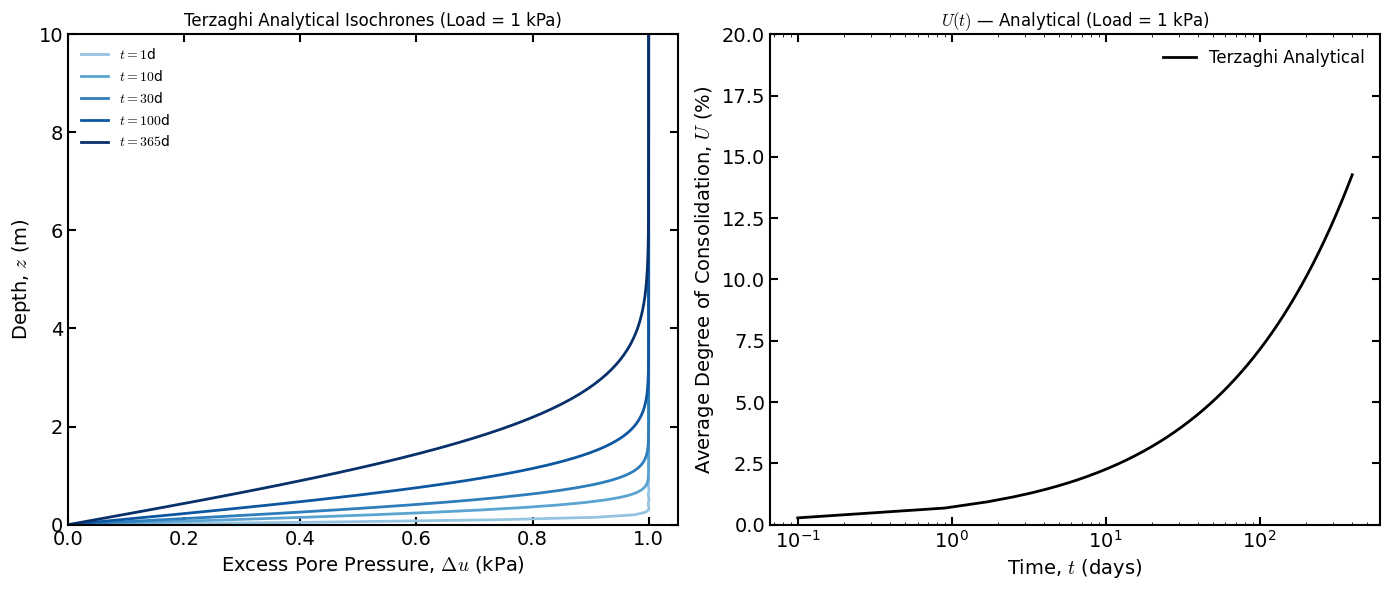

In [11]:
# =============================================================================
# CELL 11: Plot — Analytical Benchmark (Load = 1 kPa)
# =============================================================================
if PYVISTA_AVAILABLE:
    ls_reader_1kpa = pv.get_reader('output/large_strain_load_-1.e')
    ss_reader_1kpa = pv.get_reader('output/small_strain_load_-1.e')

    print("── Figure 1: Pore Pressure vs Depth (Analytical Benchmark) ──")
    plot_pore_pressure_vs_depth_analytical(
        ls_reader   = ls_reader_1kpa,
        ss_reader   = ss_reader_1kpa,
        times_p     = [1, 10, 30, 100, 365],
        H           = H_DRAINAGE,
        u0_load     = U0_LOAD,
        Cv          = CV_CALC,
        save_path   = 'output/plots/analytical_strain_comparison_plot_load_-1'
    )

    print("── Figure 2: Degree of Consolidation (Analytical Benchmark) ──")
    plot_degree_of_consolidation_analytical(
        ls_reader   = ls_reader_1kpa,
        ss_reader   = ss_reader_1kpa,
        u0_load     = U0_LOAD,
        H           = H_DRAINAGE,
        Cv          = CV_CALC,
        ylim        = (0, 20),
        save_path   = 'output/plots/degree_of_consolidation_comparison'
    )
else:
    print("PyVista not available — showing standalone analytical solution only.")

    # Standalone demonstration using only the analytical functions
    times_demo = [1, 10, 30, 100, 365]
    colors_demo = plt.cm.Blues(np.linspace(0.4, 1.0, len(times_demo)))
    z_demo      = np.linspace(0, H_DRAINAGE, 200)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: isochrones
    ax = axes[0]
    for t, c in zip(times_demo, colors_demo):
        u_t = terzaghi_analytical(z_demo, t, U0_LOAD, H_DRAINAGE, CV_CALC)
        ax.plot(u_t, z_demo, color=c, linewidth=2, label=f'$t={t}$d')
    ax.invert_yaxis()
    ax.set_xlabel(r"Excess Pore Pressure, $\Delta u$ (kPa)")
    ax.set_ylabel(r"Depth, $z$ (m)")
    ax.set_xlim(left=0)
    ax.set_ylim(0, H_DRAINAGE)
    ax.legend(fontsize=10)
    ax.set_title('Terzaghi Analytical Isochrones (Load = 1 kPa)')

    # Right: U(t)
    t_arr = np.linspace(0.1, 400, 500)
    U_arr = terzaghi_degree_of_consolidation(t_arr, CV_CALC, H_DRAINAGE)
    ax2   = axes[1]
    ax2.plot(t_arr, U_arr * 100, 'k-', linewidth=2, label='Terzaghi Analytical')
    ax2.set_xscale('log')
    ax2.set_xlabel(r"Time, $t$ (days)")
    ax2.set_ylabel(r"Average Degree of Consolidation, $U$ (%)")
    ax2.set_ylim(0, 20)
    ax2.legend()
    ax2.set_title(r'$U(t)$ — Analytical (Load = 1 kPa)')

    plt.tight_layout()
    plt.show()

---
## 12. Results: Classical Model – Load = 100 kPa

At 100 kPa, the small-strain and large-strain formulations **begin to separate**. The small-strain model treats the geometry and drainage path as fixed; the large-strain model updates $\mathbf{F}$ and $J$ at every Newton iteration, reflecting the changing volume of the porous skeleton.

The small-strain model **overpredicts** the rate of consolidation (higher $U$ for a given time) because it does not account for the increase in drainage path length as the soil column compresses.

In [12]:
# =============================================================================
# CELL 12: Plot — Classical Model, Load = 100 kPa
# =============================================================================
if PYVISTA_AVAILABLE:
    ls_reader_100 = pv.get_reader('output/large_strain_load_-100.e')
    ss_reader_100 = pv.get_reader('output/small_strain_load_-100.e')

    print("── Figure 3: Pore Pressure vs Depth (Load = 100 kPa) ──")
    plot_pore_pressure_vs_depth_moose(
        ls_reader   = ls_reader_100,
        ss_reader   = ss_reader_100,
        times_p     = [1, 10, 30, 100, 365],
        H           = H_DRAINAGE,
        save_path   = 'output/plots/large_vs_small_strain_comparison_plot_load_-100'
    )

    print("── Figure 4: Degree of Consolidation (Load = 100 kPa) ──")
    plot_degree_of_consolidation_moose(
        ls_reader   = ls_reader_100,
        ss_reader   = ss_reader_100,
        u0_load     = 100.0,
        H           = H_DRAINAGE,
        ylim        = (0, 20),
        save_path   = 'output/plots/degree_of_consolidation_load_-100'
    )
else:
    print("PyVista not available — skipping MOOSE exodus plots for 100 kPa case.")
    print("Run MOOSE simulations first, then re-execute this cell.")

PyVista not available — skipping MOOSE exodus plots for 100 kPa case.
Run MOOSE simulations first, then re-execute this cell.


---
## 13. Results: Classical Model – Load = 500 kPa

The 500 kPa case makes the divergence between the two formulations **much more pronounced**. The geometric shortening of the column under a 500 kPa load is substantial enough that:

1. The **effective drainage path** $H(t)$ in the large-strain model decreases over time, slowing consolidation.
2. The **quadratic terms** in $\mathbf{E}$ contribute significantly to the strain measure — neglecting them (small strain) yields an increasingly wrong prediction.
3. The **deformation-dependent permeability** $\mathbf{K}_{\mathrm{TL}}$ in the large-strain formulation evolves as pore volume changes.

In [13]:
# =============================================================================
# CELL 13: Plot — Classical Model, Load = 500 kPa
# =============================================================================
if PYVISTA_AVAILABLE:
    ls_reader_500 = pv.get_reader('output/large_strain_load_-500.e')
    ss_reader_500 = pv.get_reader('output/small_strain_load_-500.e')

    print("── Figure 5: Pore Pressure vs Depth (Load = 500 kPa) ──")
    plot_pore_pressure_vs_depth_moose(
        ls_reader   = ls_reader_500,
        ss_reader   = ss_reader_500,
        times_p     = [1, 10, 30, 100, 365],
        H           = H_DRAINAGE,
        save_path   = 'output/plots/large_vs_small_strain_comparison_plot_load_-500'
    )

    print("── Figure 6: Degree of Consolidation (Load = 500 kPa) ──")
    plot_degree_of_consolidation_moose(
        ls_reader   = ls_reader_500,
        ss_reader   = ss_reader_500,
        u0_load     = 500.0,
        H           = H_DRAINAGE,
        ylim        = (0, 20),
        save_path   = 'output/plots/degree_of_consolidation_comparison_load_-500'
    )
else:
    print("PyVista not available — skipping MOOSE exodus plots for 500 kPa case.")

PyVista not available — skipping MOOSE exodus plots for 500 kPa case.


---
## 14. Results: Bi-layer Model – Load = 1 kPa

The bilayer model introduces **stratigraphic contrast**: a soft upper clay (Layer 1, $\mu = 362.25$ kPa, $e_0 = 2.5$, $\kappa/\mu_f = 10^{-6}$) over a stiffer lower clay (Layer 2, $\mu = 1293.75$ kPa, $e_0 = 0.5$, $\kappa/\mu_f = 10^{-7}$).

Even at 1 kPa, the **kink in the pressure isochrones** at 2 m depth reveals the layer interface — pore pressure dissipates faster in the more permeable upper layer. However, since the load is small, the two formulations still agree closely.

In [14]:
# =============================================================================
# CELL 14: Plot — Bilayer Model, Load = 1 kPa
# =============================================================================
TIMES_BILAYER   = [730.0, 1606.0, 2518.0, 3248.0]
LABELS_BILAYER  = ['2.0yr', '4.4yr', '6.9yr', '8.9yr']
H_BILAYER       = 5.0    # Total column height [m]
LAYER_INTERFACE = 2.0    # Depth of soft/stiff interface [m]

if PYVISTA_AVAILABLE:
    ls_reader_bi1 = pv.get_reader('output/bilayer_large_strain_load_-1.e')
    ss_reader_bi1 = pv.get_reader('output/bilayer_small_strain_load_-1.e')

    print("── Figure 7: Bilayer Isochrones (Load = 1 kPa) ──")
    plot_bilayer_isochrones(
        ls_reader       = ls_reader_bi1,
        ss_reader       = ss_reader_bi1,
        times_days      = TIMES_BILAYER,
        time_labels     = LABELS_BILAYER,
        H               = H_BILAYER,
        layer_interface = LAYER_INTERFACE,
        xlim            = (0, 1.5),
        save_path       = 'output/plots/bilayer_strain_comparison_isochrones_-1'
    )

    print("── Figure 8: Bilayer Degree of Consolidation (Load = 1 kPa) ──")
    plot_bilayer_degree_of_consolidation(
        ls_reader  = ls_reader_bi1,
        ss_reader  = ss_reader_bi1,
        xlim_years = (0, 8.7),
        ylim       = (0, 105),
        save_path  = 'output/plots/bilayer_degree_of_consolidation_-1'
    )
else:
    print("PyVista not available — skipping bilayer 1 kPa plots.")

PyVista not available — skipping bilayer 1 kPa plots.


---
## 15. Results: Bi-layer Model – Load = 100 kPa / 150 kPa

At higher loads, the soft clay layer (with $e_0 = 2.5$) undergoes **large geometric changes** that violate the infinitesimal strain assumption. The large-strain model captures:

- **Thinning of Layer 1** (reducing the drainage path through the soft layer)
- **Non-linear void ratio evolution** driving permeability change
- **Asymmetric consolidation rates** between layers

The small-strain model, treating everything as fixed, significantly **overpredicts** $U(t)$. The 150 kPa case (`advanced_plots_150.py`) uses the Gibson large-strain formulation for the bilayer system.

In [15]:
# =============================================================================
# CELL 15a: Plot — Bilayer Model, Load = 100 kPa
# =============================================================================
if PYVISTA_AVAILABLE:
    ls_reader_bi100 = pv.get_reader('output/bilayer_large_strain_load_-100.e')
    ss_reader_bi100 = pv.get_reader('output/bilayer_small_strain_load_-100.e')

    print("── Figure 9: Bilayer Isochrones (Load = 100 kPa) ──")
    plot_bilayer_isochrones(
        ls_reader       = ls_reader_bi100,
        ss_reader       = ss_reader_bi100,
        times_days      = TIMES_BILAYER,
        time_labels     = LABELS_BILAYER,
        H               = H_BILAYER,
        layer_interface = LAYER_INTERFACE,
        xlim            = (0, 150),
        save_path       = 'output/plots/bilayer_strain_comparison_isochrones_-100'
    )

    print("── Figure 10: Bilayer Degree of Consolidation (Load = 100 kPa) ──")
    plot_bilayer_degree_of_consolidation(
        ls_reader  = ls_reader_bi100,
        ss_reader  = ss_reader_bi100,
        xlim_years = (0, 8.7),
        ylim       = (0, 105),
        save_path  = 'output/plots/bilayer_degree_of_consolidation_-100'
    )
else:
    print("PyVista not available — skipping bilayer 100 kPa plots.")

PyVista not available — skipping bilayer 100 kPa plots.


In [16]:
# =============================================================================
# CELL 15b: Plot — Bilayer Model, Load = 150 kPa (Gibson large-strain formulation)
# =============================================================================
if PYVISTA_AVAILABLE:
    ls_reader_bi150 = pv.get_reader('output/bilayer_large_strain_load_-150.e')
    ss_reader_bi150 = pv.get_reader('output/small_strain_load_-150.e')

    print("── Figure 11: Bilayer Isochrones (Load = 150 kPa) ──")
    plot_bilayer_isochrones(
        ls_reader       = ls_reader_bi150,
        ss_reader       = ss_reader_bi150,
        times_days      = TIMES_BILAYER,
        time_labels     = LABELS_BILAYER,
        H               = H_BILAYER,
        layer_interface = LAYER_INTERFACE,
        xlim            = (0, 2.0),
        save_path       = 'output/plots/bilayer_strain_comparison_isochrones_-150'
    )

    print("── Figure 12: Bilayer Degree of Consolidation (Load = 150 kPa) ──")
    plot_bilayer_degree_of_consolidation(
        ls_reader  = ls_reader_bi150,
        ss_reader  = ss_reader_bi150,
        xlim_years = (0, 8.7),
        ylim       = (0, 105),
        save_path  = 'output/plots/bilayer_degree_of_consolidation_-150_2'
    )
else:
    print("PyVista not available — skipping bilayer 150 kPa plots.")

PyVista not available — skipping bilayer 150 kPa plots.


---
## 16. Discussion

### 16.1 Load Dependency and Non-linearity

The results show a clear hierarchy:

| Load | Small vs Large Strain Agreement |
|------|----------------------------------|
| 1 kPa | **Excellent** — both formulations reduce to Terzaghi |
| 100 kPa | **Moderate divergence** — small strain begins to overpredict $U(t)$ |
| 500 kPa | **Large divergence** — small strain is qualitatively wrong |

This behaviour is explained by the **Green–Lagrange strain**:

$$\mathbf{E} = \frac{1}{2}\left(\nabla_0\mathbf{u} + \nabla_0\mathbf{u}^T + \underbrace{\nabla_0\mathbf{u}^T\nabla_0\mathbf{u}}_{\text{omitted in small strain}}\right)$$

For a load of 500 kPa on a 10 m column with $\mu = 2000$ kPa, the axial strain is $\sim 12.5\%$, making the quadratic term comparable in magnitude to the linear terms.

### 16.2 Material Sensitivity in Complex Stratigraphy

In the bilayer model, the soft clay layer with $e_0 = 2.5$ is highly compressible. The large void ratio means even moderate loads produce large volumetric deformation:

$$\Delta e \sim e_0 \cdot \Delta\varepsilon_v \quad \Rightarrow \quad \text{large void ratio} = \text{large pore volume change}$$

This violates the Cauchy infinitesimal strain assumption $\|\nabla_0\mathbf{u}\| \ll 1$, and the large-strain Green–Lagrange formulation is physically necessary.

### 16.3 Real-World Implications: The Staufen Disaster

In 2007, geothermal drilling in Staufen, Germany accidentally connected an anhydrite layer to a groundwater aquifer. Anhydrite hydration into gypsum caused **massive subsurface swelling** — a classic large-volumetric-change problem:

- Ground uplift: **>12 cm** at ~1 cm/year
- Building cracks: **up to 15 cm** wide  
- Damage to **270+ buildings**, repair costs **>€50 million**

A small-strain model would have completely failed to predict this response. The large-strain (finite-deformation) framework is not optional in such scenarios — it is an engineering necessity.

---
## 17. Conclusion

This project compared small-strain and large-strain formulations for 1D poromechanical consolidation using MOOSE FEM.

**Key findings:**

1. **Benchmark validation:** At 1 kPa, both formulations reproduce the Terzaghi analytical solution — confirming the correctness of the FEM implementation.

2. **Load-dependent error:** The error from small-strain kinematics increases with load because the omitted quadratic terms in $\mathbf{E}$ become increasingly significant.

3. **Stratigraphic amplification:** In layered soils, material contrast amplifies the effect — the soft layer controls deformation, while the low-permeability stiff layer controls pressure dissipation. The large-strain model captures both effects through $J$, $\mathbf{F}$, and $\mathbf{K}_{\mathrm{TL}}$.

4. **Engineering verdict:** Small-strain (Terzaghi) theory is an efficient baseline for stiff soils and low loads. For soft soils, large settlements, or strongly layered deposits, **large-strain (Gibson) theory is an engineering imperative**.

5. **MOOSE implementation:** The Total Lagrangian weak form maps directly onto MOOSE kernels. The `LargeStrainBiotDivergenceAD` kernel ($\alpha\dot{J}$ term) and deformation-dependent `LargeStrainDiffusionAndStorageAD` kernel ($\mathbf{K}_{\mathrm{TL}}$) are the two critical elements that distinguish the large-strain physics from the small-strain counterpart.

---
## 18. References

1. Atlas Obscura. (n.d.). *The cracks of Staufen*. https://www.atlasobscura.com/places/staufen-germany

2. de Borst, R., Irzal, F., Remmers, J. J. C., & Huyghe, J. M. (2013). A large deformation formulation for fluid flow in a progressively fracturing porous material. *Computer Methods in Applied Mechanics and Engineering*, *256*, 29–37.

3. Idaho National Laboratory. (n.d.). *MOOSE: Multiphysics Object-Oriented Simulation Environment*. https://mooseframework.inl.gov/

4. López Pineda, G. (2025, April 12). *Finite element solution of Terzaghi's 1D consolidation equation with spatially variable initial pore pressure* [White paper].

5. Spiezia, N., Ceccato, F., Salomoni, V., & Simonini, P. (2015, June). Simulation of consolidation in large strains: A comparison between FEM and MPM. *COUPLED PROBLEMS 2015*, Venice, Italy.

6. Terzaghi, K. (1943). *Theoretical Soil Mechanics*. John Wiley & Sons.

7. Veiskarami, M. (2013). Updated Lagrangian large deformation analysis of consolidation settlement with FEM for a case study in Iran. *Scientia Iranica*, *20*(4), 1–14.